<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/Tugas_1_18223086.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load File CSV**

In [ ]:
import pandas as pd

# Load data
df = pd.read_csv('weather_station_data.csv')

print("Berhasil load dataset.")

Berhasil load dataset.


# **1. Data Profiling**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# a) Number of rows and columns
print("a) Bentuk dataset (baris, kolom):", df.shape)

# b) Missing values per column
print("\nb) Jumlah Missing values per kolom:")
print(df.isnull().sum())

# c) Min, max, mean, std for numeric columns
print("\nc) Statistik Deskriptif (Min, Max, Mean, Std):")
summary = df.describe().T[['min', 'max', 'mean', 'std']]
print(summary)

# d) Column with zero standard deviation
print("\nd) Kolom dengan Standard Deviation = 0:")
numeric_cols_std = df.std(numeric_only=True)
zero_std_cols = numeric_cols_std[numeric_cols_std == 0].index.tolist()
print(zero_std_cols)

a) Bentuk dataset (baris, kolom): (50, 6)

b) Jumlah Missing values per kolom:
timestamp          0
temperature_C      2
humidity_pct       1
pressure_hPa       2
wind_speed_ms      1
light_level_lux    0
dtype: int64

c) Statistik Deskriptif (Min, Max, Mean, Std):
                     min        max          mean           std
temperature_C      22.73      32.49     27.033542      2.628890
humidity_pct      -15.00     150.00     61.825918     19.246522
pressure_hPa     1012.29  101395.14  19820.113125  39564.000299
wind_speed_ms       1.00       4.80      3.034694      1.142290
light_level_lux   450.00     450.00    450.000000      0.000000

d) Kolom dengan Standard Deviation = 0:
['light_level_lux']


# **2. Identify All Error Types**

## Konversi Kolom Timestamp
Konversi kolom 'timestamp' ke format datetime untuk mendapatkan waktu yang akurat.


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Tipe data kolom 'timestamp' setelah konversi:")
print(df['timestamp'].dtype)

Tipe data kolom 'timestamp' setelah konversi:
datetime64[ns]


## Visualisasi Data Time Series

Membuat plot time series untuk kolom numerik 'temperature_C', 'humidity_pct', 'pressure_hPa', dan 'wind_speed_ms' untuk mengidentifikasi pola, outlier, dan inlier secara visual.


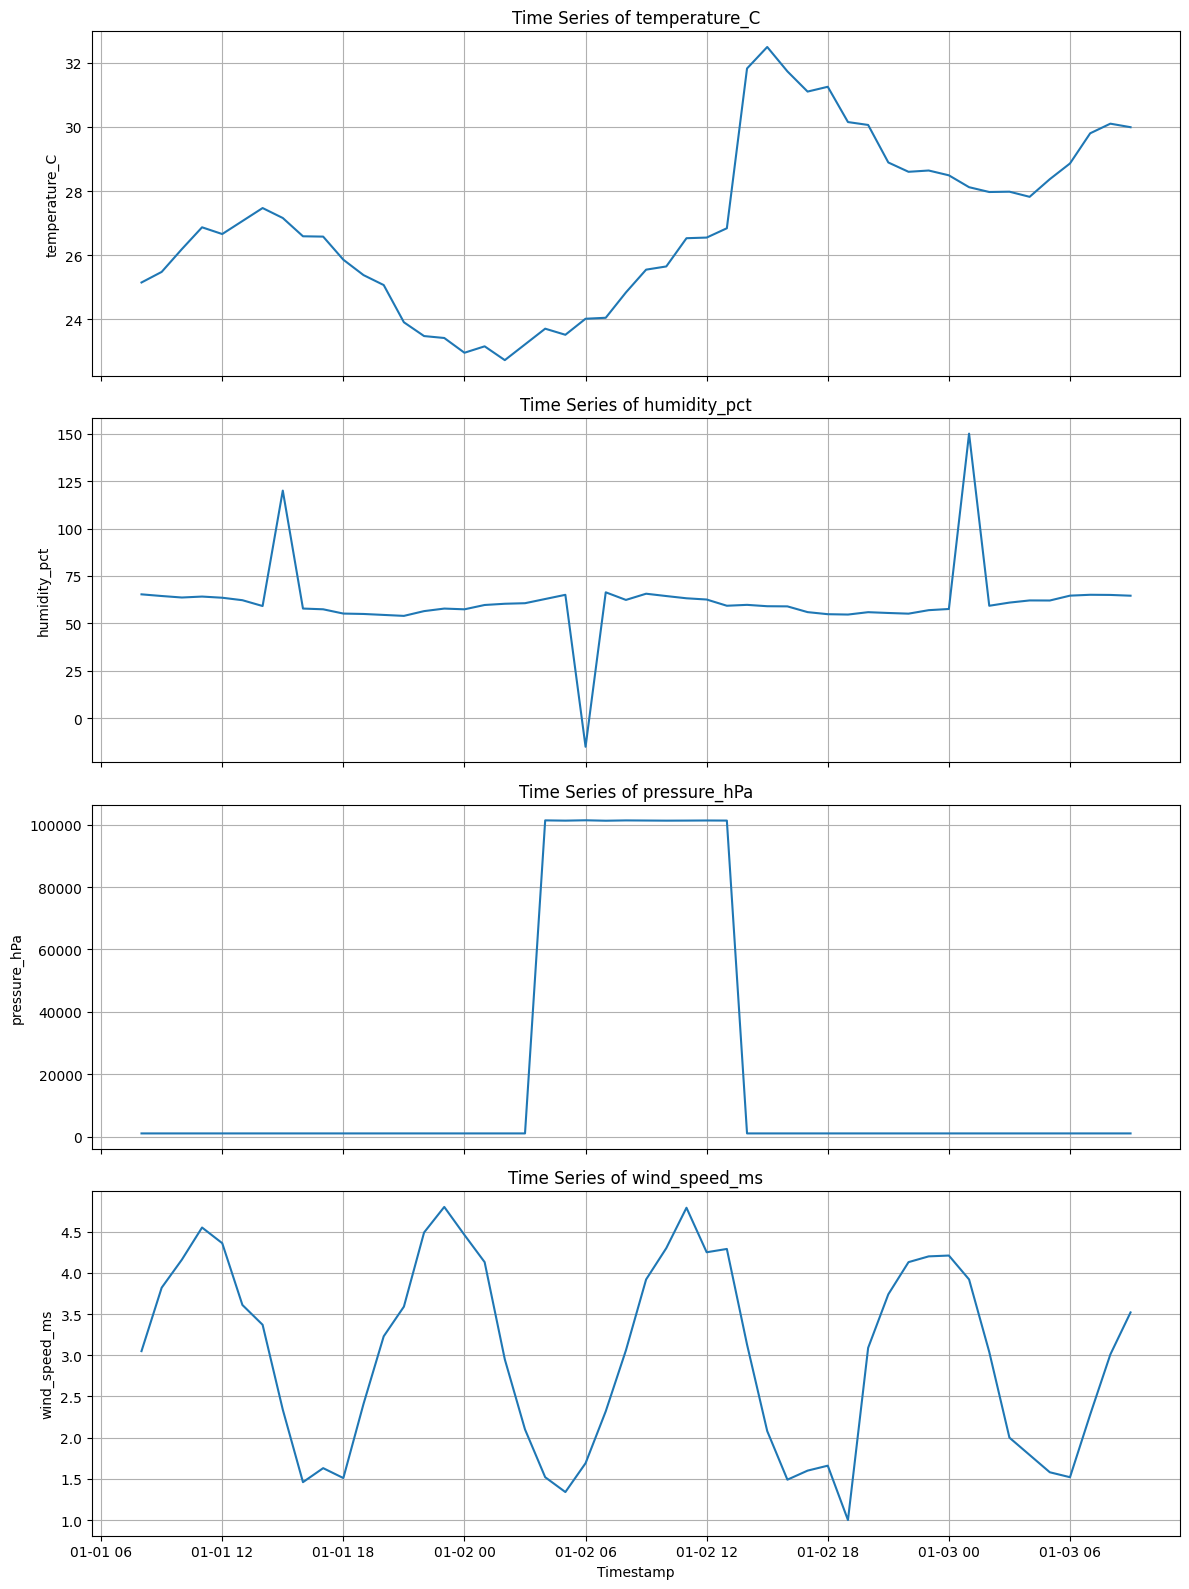

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot kolom-kolom ini
columns_to_plot = ['temperature_C', 'humidity_pct', 'pressure_hPa', 'wind_speed_ms']

fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=1, figsize=(12, 16), sharex=True)

for i, col in enumerate(columns_to_plot):
    sns.lineplot(data=df, x='timestamp', y=col, ax=axes[i])
    axes[i].set_title(f'Time Series of {col}')
    axes[i].set_xlabel('Timestamp')
    axes[i].set_ylabel(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## Visualisasi Distribusi Data

Membuat histogram untuk kolom numerik 'temperature_C', 'humidity_pct', 'pressure_hPa', dan 'wind_speed_ms' untuk memeriksa distribusi nilai dan mengidentifikasi anomali seperti nilai di luar rentang yang valid atau kesalahan unit.


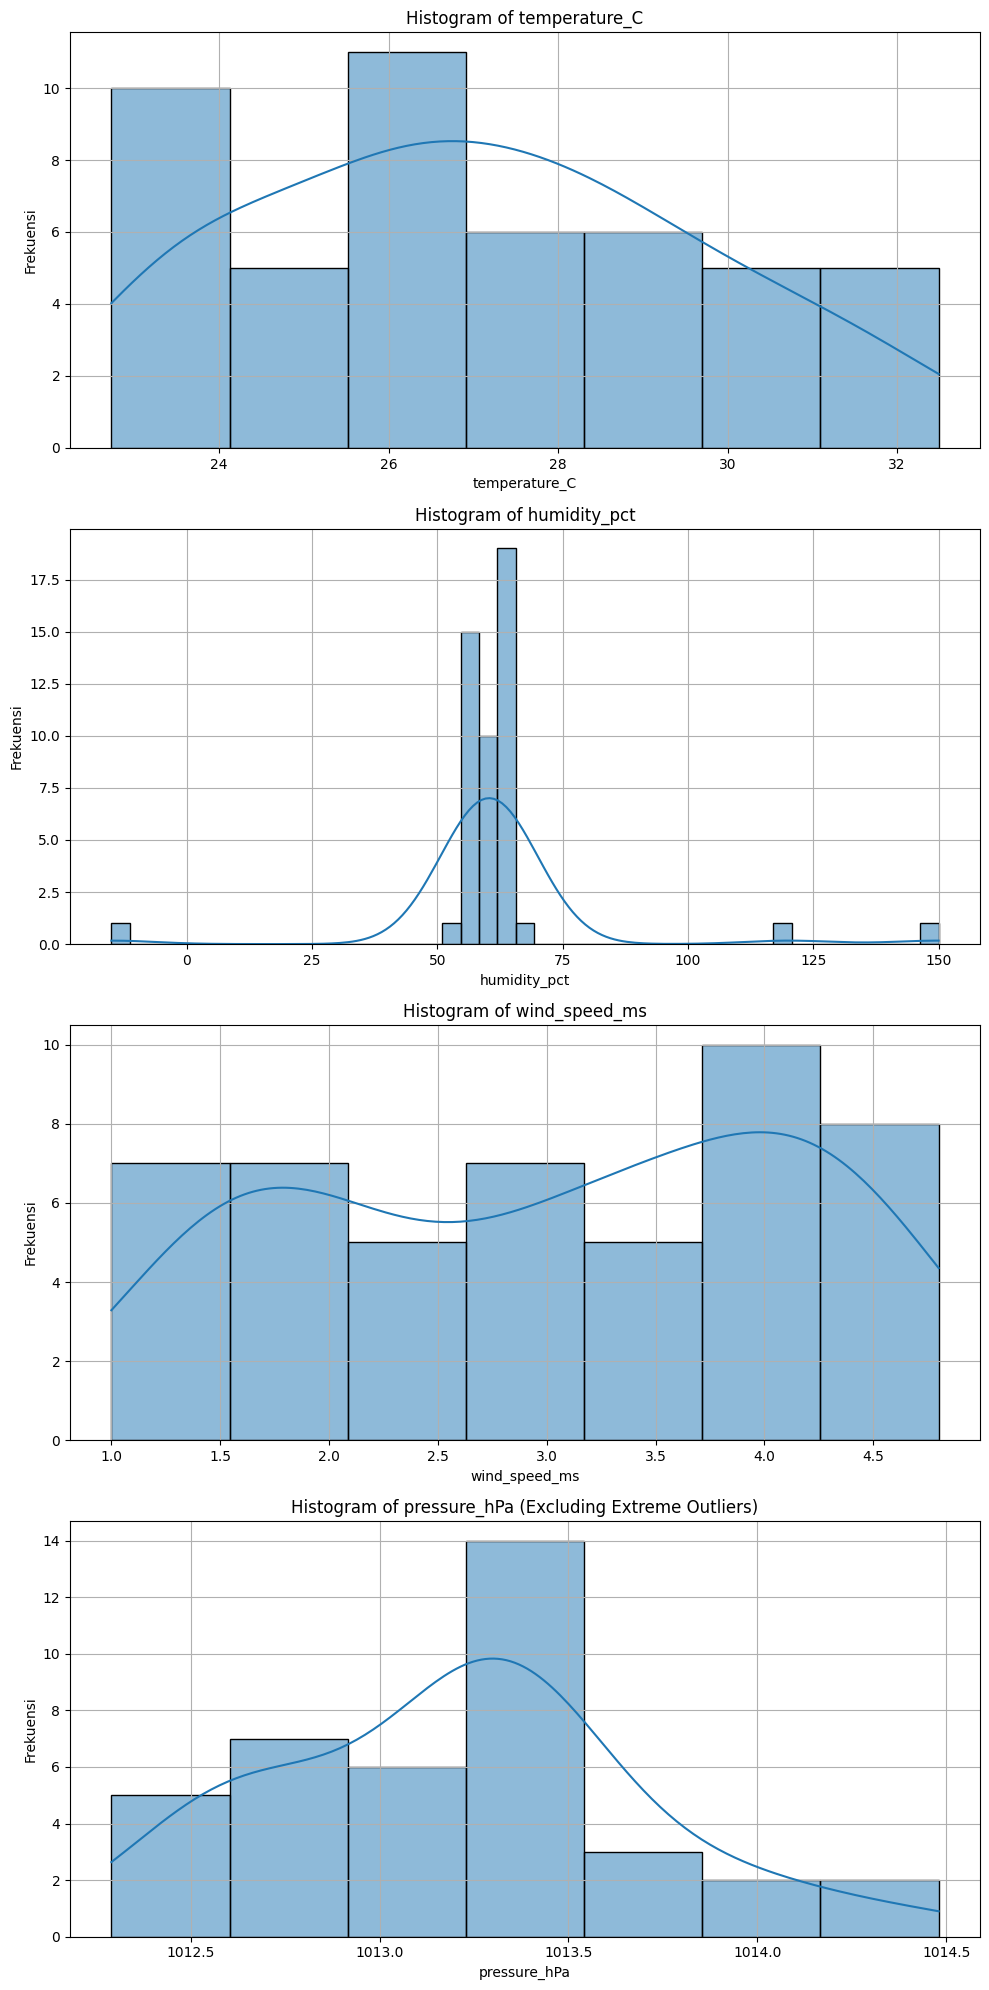

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot kolom-kolom ini
columns_for_hist = ['temperature_C', 'humidity_pct', 'wind_speed_ms']

fig, axes = plt.subplots(nrows=len(columns_for_hist) + 1, ncols=1, figsize=(10, 20))

for i, col in enumerate(columns_for_hist):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].grid(True)

# Histogram kolom pressure_hPa dibuat terpisah karena ada anomali yang sangat jauh dari
# rentang normal sehingga perlu penyesuaian
pres_col_index = len(columns_for_hist)
sns.histplot(data=df[df['pressure_hPa'] < 2000], x='pressure_hPa', kde=True, ax=axes[pres_col_index])
axes[pres_col_index].set_title('Histogram of pressure_hPa (Excluding Extreme Outliers)')
axes[pres_col_index].set_xlabel('pressure_hPa')
axes[pres_col_index].set_ylabel('Frekuensi')
axes[pres_col_index].grid(True)

plt.tight_layout()
plt.show()

## Identifikasi dan Klasifikasi Kesalahan



Berdasarkan analisis statistik (`df.describe()`, `df.isnull().sum()`, `zero_std_cols`) dan visualisasi (time series plots, histograms), berikut adalah identifikasi dan klasifikasi setidaknya 5 jenis kesalahan yang berbeda dalam dataset:


1.  **Missing Values (Stochastic Error)**
    *   **Variabel Terpengaruh**: `temperature_C`, `humidity_pct`, `pressure_hPa`, `wind_speed_ms`
    *   **Penjelasan**: Dari `df.isnull().sum()`:
        *   `temperature_C`: 2 missing values
        *   `humidity_pct`: 1 missing value
        *   `pressure_hPa`: 2 missing values
        *   `wind_speed_ms`: 1 missing value
        
        Missing values ini dapat diklasifikasikan sebagai _Stochastic Error_ karena kemungkinan terjadi secara acak atau tidak terduga, datanya tidak menunjukkan pola sistematis yang konsisten.

2.  **Outlier / Deterministic Error (Humidity Percentage)**
    *   **Variabel Terpengaruh**: `humidity_pct`
    *   **Penjelasan**: Dari `df.describe()` dan histogram, nilai minimum `humidity_pct` adalah `-15.00` dan maksimum adalah `150.00`. Kelembaban relatif tidak mungkin bernilai negatif atau melebihi 100%. Ini menunjukkan _Outlier_ yang signifikan dan kemungkinan besar merupakan _Deterministic Error_ akibat kalibrasi sensor yang salah atau unit pengukuran yang tidak tepat, atau kesalahan pemrosesan data. Ini adalah kesalahan sistematis karena nilai-nilai tersebut secara fisik tidak mungkin.

3.  **Outlier / Deterministic Error (Pressure Units)**
    *   **Variabel Terpengaruh**: `pressure_hPa`
    *   **Penjelasan**: Dari `df.describe()`, nilai maksimum `pressure_hPa` adalah `101395.14`. Tekanan atmosfer normal berada di kisaran 900-1100 hPa. Nilai `101395.14` secara signifikan berada di luar jangkauan yang wajar. Ini adalah _Deterministic Error_ karena bersifat sistematis dan menunjukkan masalah pada proses pengukuran atau pencatatan, bukan fluktuasi acak.

4.  **Constant Feature**
    *   **Variabel Terpengaruh**: `light_level_lux`
    *   **Penjelasan**: Dari output `df.describe()` dan `zero_std_cols`, kolom `light_level_lux` memiliki nilai minimum `450.00` dan maksimum `450.00`, serta standar deviasi `0.00`. Ini menunjukkan bahwa semua nilai dalam kolom ini sama. Ini diklasifikasikan sebagai _Constant Feature_. Meskipun bukan berarti salah, namun cukup janggal jika seharusnya kolom ini menunjukkan variasi.

5.  **Inlier**
    *   **Variabel Terpengaruh**: `temperature_C`, `wind_speed_ms`
    *   **Penjelasan**: Visualisasi time series dapat membantu mendeteksi pola aneh inlier yang masih di dalam rentang normal. Sebagai contoh, fluktuasi `temperature_C` dan `wind_speed_ms` yang terlihat acak namun tidak ekstrem di dalam plot time series bisa jadi merupakan _Stochastic Error_ yang termanifestasi sebagai inlier. Namun menurut saya ini adalah tipe kesalahan yang lebih sulit diidentifikasi tanpa data pembanding atau model yang lebih canggih.

## **3. Propose Handling Methods**


Berdasarkan identifikasi kesalahan sebelumnya, berikut adalah usulan metode penanganan untuk setiap jenis kesalahan:


1.  **Missing Values (Stochastic Error)**
    *   **Variabel Terpengaruh**: `temperature_C`, `humidity_pct`, `pressure_hPa`, `wind_speed_ms`
    *   **Metode Penanganan**: **Interpolasi Temporal (misalnya, `df.interpolate(method='time')` atau `df.interpolate(method='linear')`)**.
    *   **Alasan**: Karena ini adalah data *time series* dan jumlah nilai yang hilang relatif kecil, interpolasi adalah metode yang tepat. Interpolasi temporal atau linear akan mengisi nilai yang hilang berdasarkan tren data di sekitarnya. Ini lebih baik daripada menghapus baris karena dapat menyebabkan hilangnya informasi berharga lainnya.

2.  **Outlier / Deterministic Error (Humidity Percentage)**
    *   **Variabel Terpengaruh**: `humidity_pct`
    *   **Metode Penanganan**: **Capping/Clamping (pembatasan nilai)**.
    *   **Alasan**: Nilai kelembaban negatif atau di atas 100% secara fisik tidak mungkin. Oleh karena itu, kita dapat membatasi nilai-nilai ini ke rentang yang valid: nilai negatif diubah menjadi 0 dan nilai di atas 100% diubah menjadi 100. Ini secara langsung mengoreksi data ke batas fisika yang masuk akal tanpa menginterpolasi atau menghapus, yang mungkin menyembunyikan masalah kalibrasi sensor.

3.  **Outlier / Deterministic Error (Pressure Units)**
    *   **Variabel Terpengaruh**: `pressure_hPa`
    *   **Metode Penanganan**: **Koreksi Unit Pengukuran**.
    *   **Alasan**: Nilai ekstrem seperti `101395.14` sangat kuat mengindikasikan kesalahan unit, di mana data mungkin dicatat dalam Pascal (Pa) daripada hektopascal (hPa). Langkah pertama adalah mengidentifikasi dan membagi nilai-nilai tersebut dengan faktor konversi (100) untuk mengubahnya ke hPa yang benar. Sehingga nilainya menjadi dalam batas wajar.

4.  **Constant Feature**
    *   **Variabel Terpengaruh**: `light_level_lux`
    *   **Metode Penanganan**: **Hapus Kolom**.
    *   **Alasan**: Kolom dengan standar deviasi nol (konstan) tidak memberikan informasi atau variasi apapun untuk analisis atau pemodelan. Dalam konteks ini, `light_level_lux` yang selalu 450.00 tidak akan berkontribusi pada pemahaman pola cuaca. Menghapusnya adalah cara yang efisien untuk mengurangi dimensi data tanpa kehilangan informasi yang berarti.

5.  **Inlier**
    *   **Variabel Terpengaruh**: `temperature_C`, `wind_speed_ms`
    *   **Metode Penanganan**: **Analisis Lebih Lanjut**.
    *   **Alasan**: Inlier sangat sulit dideteksi dengan metode statistik sederhana karena mereka berada dalam rentang nilai yang valid. Mereka memerlukan analisis lebih lanjut untuk mengidentifikasi inkonsistensi lokal. Untuk tugas ini, tanpa data pembanding atau model yang lebih canggih, mengidentifikasi bahwa mereka membutuhkan metode deteksi anomali yang lebih canggih atau tinjauan ahli adalah penanganan yang paling tepat.

## **4. Summary Table**

| Error label                                 | Variable                                     | Rows affected                               | Error Type          | Proposed Handling Method                                                                                                                              |
| :------------------------------------------ | :------------------------------------------- | :------------------------------------------ | :------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------- |
| Missing Values                              | `temperature_C`, `humidity_pct`, `pressure_hPa`, `wind_speed_ms` | `temperature_C`: 2, `humidity_pct`: 1, `pressure_hPa`: 2, `wind_speed_ms`: 1 | Stochastic Error    | Interpolasi Temporal (`df.interpolate(method='time')` atau `df.interpolate(method='linear')`)                                                         |
| Outlier / Deterministic Error (Invalid Humidity Range) | `humidity_pct`                               | Multiple rows (values < 0 or > 100%)        | Deterministic Error, Outlier | Capping/Clamping (nilai negatif diubah menjadi 0, nilai > 100% diubah menjadi 100)                                                                        |
| Outlier / Deterministic Error (Wrong Pressure Unit) | `pressure_hPa`                               | Multiple rows (values > normal hPa range, likely Pascal) | Deterministic Error, Outlier | Koreksi Unit Pengukuran (bagi dengan 100), kemudian interpolasi/penanganan outlier sekunder jika masih ada anomali.                                |
| Constant Feature                            | `light_level_lux`                            | All 50 rows (all values are 450.00)         | Constant Feature    | Hapus Kolom                                                                                                                             |
| Inlier (Locally Inconsistent)               | `temperature_C`, `wind_speed_ms`             | Indeterminate (requires advanced detection) | Stochastic Error, inlier   | Analisis Lebih Lanjut  |